In [1]:
# Libraries
import os                               # imports the OS library for interacting with the operating system
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis
from matplotlib import pyplot as plt    # imports the Pyplot module from the Matplotlib library for plotting

In [56]:
def search_name(file_path, name):
    with open(file_path) as file:
        text = file.read()
        if name in text:
            print('YES')
        else:
            print('NO')

In [57]:
%%time
search_name("data/bronze/texts/cthulhu.txt", 'dragon')

YES
CPU times: user 1.55 ms, sys: 822 μs, total: 2.37 ms
Wall time: 1.75 ms


In [4]:
# organizing a list with the names of all the files in the directory
file_names = os.listdir("data/silver/texts")
print(file_names)

['mountains_of_madness.txt', 'nyarlathotep.txt', 'moon_bog.txt', 'book.txt', 'other_gods.txt', 'randolph_carter.txt', 'picture_house.txt', 'cool_air.txt', 'alchemist.txt', 'nameless.txt', 'festival.txt', 'reanimator.txt', 'arthur_jermyn.txt', 'dunwich.txt', 'doorstep.txt', 'ulthar.txt', 'haunter.txt', 'crawling_chaos.txt', 'from_beyond.txt', 'dagon.txt', 'pharoahs.txt', 'juan_romero.txt', 'colour_out_of_space.txt', 'clergyman.txt', 'celephais.txt', 'iranon.txt', 'poetry_of_gods.txt', 'z_test', 'descendent.txt', 'shunned_house.txt', 'beyond_wall_of_sleep.txt', 'redhook.txt', 'outsider.txt', 'dreams_in_the_witch.txt', 'charles_dexter_ward.txt', 'pickman.txt', 'old_folk.txt', 'he.txt', 'memory.txt', 'martins_beach.txt', 'polaris.txt', 'hypnos.txt', 'ex_oblivione.txt', 'medusas_coil.txt', 'street.txt', 'erich_zann.txt', 'rats_walls.txt', 'kadath.txt', 'tree.txt', 'innsmouth.txt', 'gates_of_silver_key.txt', 'azathoth.txt', 'white_ship.txt', 'terrible_old_man.txt', 'high_house_mist.txt', 'si

In [5]:
text_dict_silver = {name[0:-4]: open( "data/silver/texts/" + name ).read()  for name in file_names}
df_texts = pd.DataFrame.from_dict(text_dict_silver, orient='index', columns=['text'])

Adding relevant information for the texts.

In [6]:
df_texts['sentence_count'] = df_texts['text'].apply(lambda x: x.count('.'))
df_texts['word_count'] = df_texts['text'].apply(lambda x: len(x.split()))
df_texts['character_count'] = df_texts['text'].apply(len)
df_texts.head()

,text,sentence_count,word_count,character_count
mountains_of_madness,AT THE MOUNTAINS OF MADNESS\n\nI\n\nI am force...,1396,40413,245865
nyarlathotep,NYARLATHOTEP\n\nNyarlathotep...the crawling ch...,55,1130,6718
moon_bog,"THE MOON BOG\n\nSomewhere, to what remote and ...",109,3413,18595
book,THE BOOK\n\nMy memories are very confused. The...,47,1146,6398
other_gods,THE OTHER GODS\n\nBut now they have betaken th...,81,1897,10325


In [7]:
%%time 
df_texts['numerical_representation'] = df_texts['text'].apply(lambda x: np.array([ord(letter) for letter in list( tuple(x) )]) )
df_texts['fourier_transform'] = df_texts['numerical_representation'].apply( lambda x: np.fft.fft(x)  )
df_texts.to_csv('data/gold/texts.csv')
df_texts.head()

CPU times: user 692 ms, sys: 140 ms, total: 831 ms
Wall time: 830 ms


,text,sentence_count,word_count,character_count,numerical_representation,fourier_transform
mountains_of_madness,AT THE MOUNTAINS OF MADNESS\n\nI\n\nI am force...,1396,40413,245865,"[65, 84, 32, 84, 72, 69, 32, 77, 79, 85, 78, 8...","[(22943370+0j), (-30215.41351469525+7042.66858..."
nyarlathotep,NYARLATHOTEP\n\nNyarlathotep...the crawling ch...,55,1130,6718,"[78, 89, 65, 82, 76, 65, 84, 72, 79, 84, 69, 8...","[(623696.0000000001-1.1368683772161603e-12j), ..."
moon_bog,"THE MOON BOG\n\nSomewhere, to what remote and ...",109,3413,18595,"[84, 72, 69, 32, 77, 79, 79, 78, 32, 66, 79, 7...","[(1708112.9999999998+6.434675015043467e-11j), ..."
book,THE BOOK\n\nMy memories are very confused. The...,47,1146,6398,"[84, 72, 69, 32, 66, 79, 79, 75, 10, 10, 77, 1...","[(587197.0000000001-2.887645678129047e-11j), (..."
other_gods,THE OTHER GODS\n\nBut now they have betaken th...,81,1897,10325,"[84, 72, 69, 32, 79, 84, 72, 69, 82, 32, 71, 7...","[(941199+0j), (-720.4067747474475-1783.9086385..."


In [ ]:
cthulhu_num = df_texts['numerical_representation']['cthulhu']  
cthulhu_fourier = df_texts['fourier_transform']['cthulhu']
print(len(cthulhu_num), df_texts['character_count']['cthulhu'])  ))

69371 69371


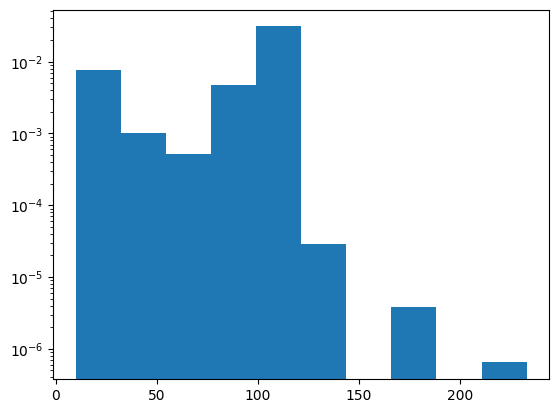

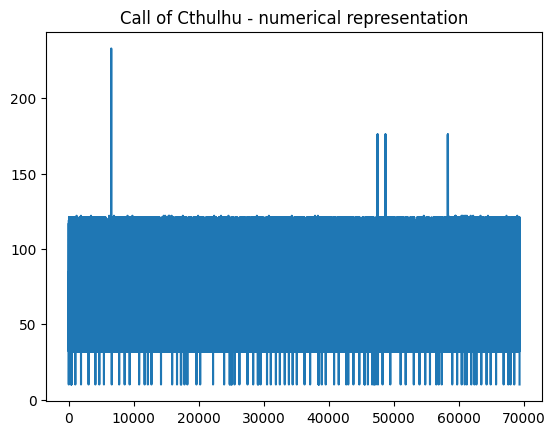

/home/dmitry/Projects/lovecraft/venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/dmitry/Projects/lovecraft/venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Call of Cthulhu - Fourier transform')

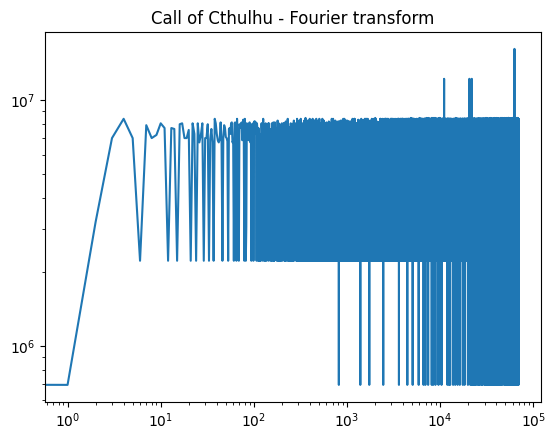

In [21]:
plt.hist(cthulhu_num, density=True)
plt.yscale('log')
plt.show()

plt.plot(cthulhu_num)
plt.title('Call of Cthulhu - numerical representation')
plt.show()

plt.plot(  np.fft.fft(cthulhu_fourier)  )
plt.xscale('log')
plt.yscale('log')
plt.title('Call of Cthulhu - Fourier transform')